# Assistive Visual Question Answering with Answerability Detection
## Complete Pipeline Notebook

| | |
|---|---|
| **Team Members** | Syed Muhammad Huzaifa Ali(30024167) · Akash Kumar Shaw(32867647) · Ishtpreet Singh(69195258) |
| **Dataset** | VizWiz VQA |
| **Notebook** | Complete pipeline — dataset download through answerability detection |

> **Note:** This notebook contains the full pipeline including dataset download and CLIP feature extraction (Phase 1), multimodal fusion and answer prediction (Phase 2) and answerability detection (Phase 3).
> Phase 1 (dataset download and feature extraction) takes significant time to run due to dataset size and CLIP inference. For a fast demo, use **Final_Project_Demo.ipynb** which loads pre-extracted features directly.


---
# Phase 1 - Dataset Understanding, Preprocessing and Feature Extraction
**Owner: Syed Muhammad Huzaifa Ali**


## 1.1 Project Setup

In [2]:
PROJECT_DIR = "/content/VizWiz_VQA_Project"

import os

folders = [
    "dataset/images",
    "dataset/annotations",
    "embeddings",
    "figures/dataset_examples",
    "models",
    "predictions",
    "results"
]

for folder in folders:
    os.makedirs(f"{PROJECT_DIR}/{folder}", exist_ok=True)

print("Project folders created at:", PROJECT_DIR)


Project folders created at: /content/VizWiz_VQA_Project


## 1.2 Check Available Disk Space

In [3]:
!df -h /content


Filesystem      Size  Used Avail Use% Mounted on
overlay         113G   48G   65G  43% /


## 1.3 Download Dataset

In [4]:
# Download train images
!wget -c https://vizwiz.cs.colorado.edu/VizWiz_final/images/train.zip -P "$PROJECT_DIR/dataset/images"

# Unzip and overwrite existing files without asking
!unzip -oq "$PROJECT_DIR/dataset/images/train.zip" -d "$PROJECT_DIR/dataset/images/"

# Delete zip file to save space
!rm "$PROJECT_DIR/dataset/images/train.zip"

print("Training images downloaded and extracted.")
!df -h /content

--2026-07-06 23:50:26--  https://vizwiz.cs.colorado.edu/VizWiz_final/images/train.zip
Resolving vizwiz.cs.colorado.edu (vizwiz.cs.colorado.edu)... 198.59.7.50
Connecting to vizwiz.cs.colorado.edu (vizwiz.cs.colorado.edu)|198.59.7.50|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 11298421598 (11G) [application/zip]
Saving to: ‘/content/VizWiz_VQA_Project/dataset/images/train.zip’

train.zip           100%[===================>]  10.52G  27.4MB/s    in 6m 8s   

2026-07-06 23:56:35 (29.2 MB/s) - ‘/content/VizWiz_VQA_Project/dataset/images/train.zip’ saved [11298421598/11298421598]

Training images downloaded and extracted.
Filesystem      Size  Used Avail Use% Mounted on
overlay         113G   59G   55G  52% /


In [5]:
# Download val images
!wget -c https://vizwiz.cs.colorado.edu/VizWiz_final/images/val.zip -P "$PROJECT_DIR/dataset/images"

!unzip -oq "$PROJECT_DIR/dataset/images/val.zip" -d "$PROJECT_DIR/dataset/images/"

!rm "$PROJECT_DIR/dataset/images/val.zip"

print("Validation images downloaded and extracted.")
!df -h /content


--2026-07-06 23:59:27--  https://vizwiz.cs.colorado.edu/VizWiz_final/images/val.zip
Resolving vizwiz.cs.colorado.edu (vizwiz.cs.colorado.edu)... 198.59.7.50
Connecting to vizwiz.cs.colorado.edu (vizwiz.cs.colorado.edu)|198.59.7.50|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 3488913457 (3.2G) [application/zip]
Saving to: ‘/content/VizWiz_VQA_Project/dataset/images/val.zip’

val.zip             100%[===================>]   3.25G  31.3MB/s    in 97s     

2026-07-07 00:01:04 (34.3 MB/s) - ‘/content/VizWiz_VQA_Project/dataset/images/val.zip’ saved [3488913457/3488913457]

Validation images downloaded and extracted.
Filesystem      Size  Used Avail Use% Mounted on
overlay         113G   62G   51G  55% /


In [6]:
# Download annotations
!wget -c https://vizwiz.cs.colorado.edu/VizWiz_final/vqa_data/Annotations.zip -P "$PROJECT_DIR/dataset/annotations"

!unzip -oq "$PROJECT_DIR/dataset/annotations/Annotations.zip" -d "$PROJECT_DIR/dataset/annotations/"

!rm "$PROJECT_DIR/dataset/annotations/Annotations.zip"

print("Annotations downloaded and extracted.")


--2026-07-07 00:02:07--  https://vizwiz.cs.colorado.edu/VizWiz_final/vqa_data/Annotations.zip
Resolving vizwiz.cs.colorado.edu (vizwiz.cs.colorado.edu)... 198.59.7.50
Connecting to vizwiz.cs.colorado.edu (vizwiz.cs.colorado.edu)|198.59.7.50|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 1711273 (1.6M) [application/zip]
Saving to: ‘/content/VizWiz_VQA_Project/dataset/annotations/Annotations.zip’

Annotations.zip     100%[===================>]   1.63M  9.43MB/s    in 0.2s    

2026-07-07 00:02:07 (9.43 MB/s) - ‘/content/VizWiz_VQA_Project/dataset/annotations/Annotations.zip’ saved [1711273/1711273]

Annotations downloaded and extracted.


## 1.4 Verify Dataset

In [9]:
import glob
import os

train_images = glob.glob(f"{PROJECT_DIR}/dataset/images/train/*.jpg")
val_images   = glob.glob(f"{PROJECT_DIR}/dataset/images/val/*.jpg")

print("Training images  :", len(train_images))
print("Validation images:", len(val_images))

json_files = glob.glob(f"{PROJECT_DIR}/dataset/annotations/**/*.json", recursive=True)
print("Annotation files :", json_files)


Training images  : 23954
Validation images: 7750
Annotation files : ['/content/VizWiz_VQA_Project/dataset/annotations/train.json', '/content/VizWiz_VQA_Project/dataset/annotations/test.json', '/content/VizWiz_VQA_Project/dataset/annotations/val.json']


## 1.5 Load Annotations

In [10]:
import json

train_json_path = [p for p in json_files if "train" in os.path.basename(p).lower()][0]
val_json_path   = [p for p in json_files if "val" in os.path.basename(p).lower()][0]

with open(train_json_path, "r") as f:
    train_data = json.load(f)

with open(val_json_path, "r") as f:
    val_data = json.load(f)

print("Train annotations:", len(train_data))
print("Val annotations  :", len(val_data))
print("First example:")
print(train_data[0])


Train annotations: 20523
Val annotations  : 4319
First example:
{'image': 'VizWiz_train_00000000.jpg', 'question': "What's the name of this product?", 'answers': [{'answer_confidence': 'yes', 'answer': 'basil leaves'}, {'answer_confidence': 'yes', 'answer': 'basil leaves'}, {'answer_confidence': 'yes', 'answer': 'basil'}, {'answer_confidence': 'yes', 'answer': 'basil'}, {'answer_confidence': 'yes', 'answer': 'basil leaves'}, {'answer_confidence': 'yes', 'answer': 'basil leaves'}, {'answer_confidence': 'yes', 'answer': 'basil leaves'}, {'answer_confidence': 'yes', 'answer': 'basil leaves'}, {'answer_confidence': 'yes', 'answer': 'basil leaves'}, {'answer_confidence': 'yes', 'answer': 'basil'}], 'answer_type': 'other', 'answerable': 1}


## 1.6 Build DataFrames and Label Processing

In [11]:
import pandas as pd
import re
from collections import Counter

def normalize_answer(ans):
    ans = str(ans).lower().strip()
    ans = re.sub(r"[^a-z0-9\s]", "", ans)
    ans = re.sub(r"\s+", " ", ans)
    return ans

def get_majority_answer(answers):
    answer_list = [normalize_answer(a["answer"]) for a in answers]
    return Counter(answer_list).most_common(1)[0][0]

def build_df(data, split):
    rows = []
    for i, item in enumerate(data):
        image_name = item["image"]
        image_path = f"{PROJECT_DIR}/dataset/images/{split}/{image_name}"

        rows.append({
            "question_id": i,
            "image": image_name,
            "image_path": image_path,
            "question": item["question"],
            "answerable": item["answerable"],
            "answer_type": item.get("answer_type", "unknown"),
            "majority_answer": get_majority_answer(item["answers"]),
            "split": split
        })

    return pd.DataFrame(rows)

train_df = build_df(train_data, "train")
val_df = build_df(val_data, "val")

print("Train dataframe:", train_df.shape)
print("Val dataframe  :", val_df.shape)

print("\nTrain size:", len(train_df))
print("Validation size:", len(val_df))

print("\nTrain answerability distribution:")
print(train_df["answerable"].value_counts())
print(train_df["answerable"].value_counts(normalize=True))

print("\nValidation answerability distribution:")
print(val_df["answerable"].value_counts())
print(val_df["answerable"].value_counts(normalize=True))

print("\nAnswer type distribution:")
print(train_df["answer_type"].value_counts())

print("\nTop 20 majority answers:")
print(train_df["majority_answer"].value_counts().head(20))

Train dataframe: (20523, 8)
Val dataframe  : (4319, 8)

Train size: 20523
Validation size: 4319

Train answerability distribution:
answerable
1    14991
0     5532
Name: count, dtype: int64
answerable
1    0.730449
0    0.269551
Name: proportion, dtype: float64

Validation answerability distribution:
answerable
1    2934
0    1385
Name: count, dtype: int64
answerable
1    0.679324
0    0.320676
Name: proportion, dtype: float64

Answer type distribution:
answer_type
other           13733
unanswerable     5532
yes/no            957
number            301
Name: count, dtype: int64

Top 20 majority answers:
majority_answer
unanswerable    7583
no               508
yes              501
white            294
grey             286
black            228
blue             214
red              129
brown            101
pink              99
keyboard          88
green             86
dog               71
purple            64
phone             60
laptop            59
soup              58
yellow           

In [12]:
import os

train_missing = train_df[~train_df["image_path"].apply(os.path.exists)]
val_missing = val_df[~val_df["image_path"].apply(os.path.exists)]

print("Missing train images:", len(train_missing))
print("Missing validation images:", len(val_missing))

Missing train images: 0
Missing validation images: 0


## 1.7 Save Full Metadata

In [13]:
import os

os.makedirs(f"{PROJECT_DIR}/embeddings", exist_ok=True)

train_df.to_csv(f"{PROJECT_DIR}/embeddings/metadata_train.csv", index=False)
val_df.to_csv(f"{PROJECT_DIR}/embeddings/metadata_val.csv", index=False)

print("Full metadata saved successfully.")
print(f"{PROJECT_DIR}/embeddings/metadata_train.csv")
print(f"{PROJECT_DIR}/embeddings/metadata_val.csv")

Full metadata saved successfully.
/content/VizWiz_VQA_Project/embeddings/metadata_train.csv
/content/VizWiz_VQA_Project/embeddings/metadata_val.csv


## 1.8 Sample Images

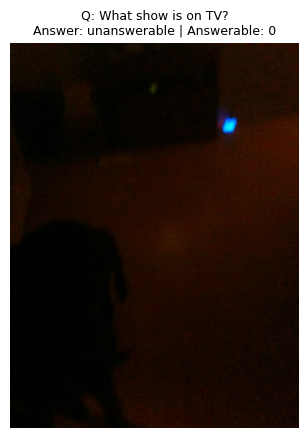

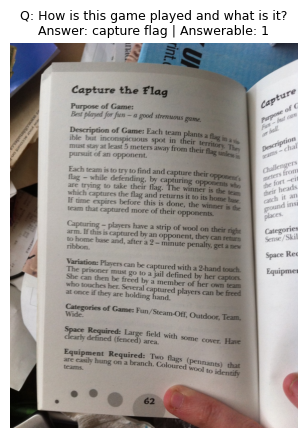

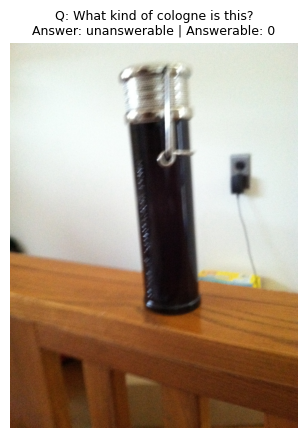

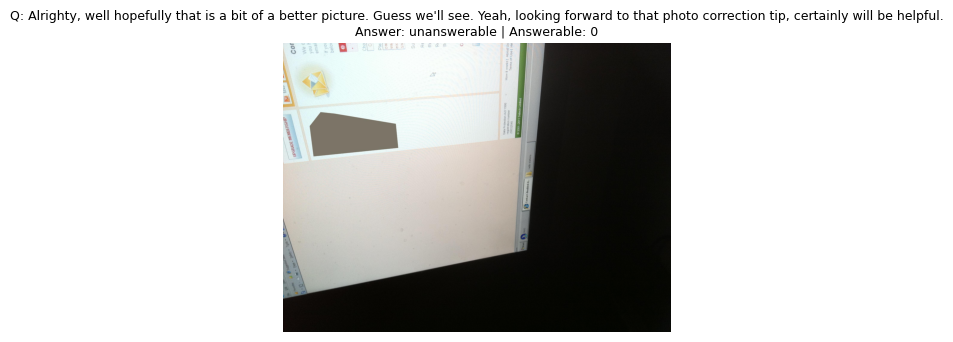

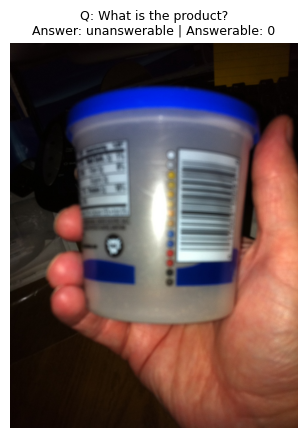

In [14]:
from PIL import Image
import matplotlib.pyplot as plt

sample_df = train_df.sample(5, random_state=42)

for _, row in sample_df.iterrows():
    img = Image.open(row["image_path"]).convert("RGB")

    plt.figure(figsize=(5, 5))
    plt.imshow(img)
    plt.axis("off")
    plt.title(
        f"Q: {row['question']}\n"
        f"Answer: {row['majority_answer']} | Answerable: {row['answerable']}",
        fontsize=9
    )
    plt.show()

## 1.9 Create Subset for Training

In [15]:
from sklearn.model_selection import train_test_split

SUBSET_FRACTION = 0.50

train_subset, _ = train_test_split(
    train_df,
    train_size=SUBSET_FRACTION,
    stratify=train_df["answerable"],
    random_state=42
)

val_subset, _ = train_test_split(
    val_df,
    train_size=SUBSET_FRACTION,
    stratify=val_df["answerable"],
    random_state=42
)

train_subset = train_subset.reset_index(drop=True)
val_subset   = val_subset.reset_index(drop=True)

print("Train subset:", train_subset.shape)
print("Val subset  :", val_subset.shape)

print("\nTrain subset answerability:")
print(train_subset["answerable"].value_counts())
print(train_subset["answerable"].value_counts(normalize=True))

print("\nValidation subset answerability:")
print(val_subset["answerable"].value_counts())
print(val_subset["answerable"].value_counts(normalize=True))



Train subset: (10261, 8)
Val subset  : (2159, 8)

Train subset answerability:
answerable
1    7495
0    2766
Name: count, dtype: int64
answerable
1    0.730436
0    0.269564
Name: proportion, dtype: float64

Validation subset answerability:
answerable
1    1467
0     692
Name: count, dtype: int64
answerable
1    0.679481
0    0.320519
Name: proportion, dtype: float64


## 1.10 Install Dependencies and Load CLIP

In [16]:
!pip install -q transformers torch torchvision pillow tqdm


In [17]:
import os
os.environ["HF_HUB_DISABLE_PROGRESS_BARS"] = "1"

from huggingface_hub.utils import disable_progress_bars
disable_progress_bars()

import torch
from transformers import CLIPProcessor, CLIPModel
from tqdm import tqdm
import numpy as np

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)

clip_model     = CLIPModel.from_pretrained("openai/clip-vit-base-patch32").to(device)
clip_processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")
_ = clip_model.eval()
print("CLIP model loaded successfully on:", device)


Using device: cuda


Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

CLIP model loaded successfully on: cuda


## 1.11 Feature Extraction with CLIP

In [ ]:
def extract_clip_features(df, batch_size=16):
    image_features = []
    question_features = []

    for i in tqdm(range(0, len(df), batch_size)):
        batch = df.iloc[i:i + batch_size]

        images = []
        questions = []

        for _, row in batch.iterrows():
            img = Image.open(row["image_path"]).convert("RGB")
            images.append(img.copy())   # copy image into memory safely
            img.close()                 # close file handle

            questions.append(str(row["question"]))

        inputs = clip_processor(
            text=questions,
            images=images,
            return_tensors="pt",
            padding=True,
            truncation=True
        ).to(device)

        with torch.no_grad():
            outputs = clip_model(**inputs)

            img_feat = outputs.image_embeds
            q_feat = outputs.text_embeds

            img_feat = img_feat / img_feat.norm(dim=-1, keepdim=True)
            q_feat = q_feat / q_feat.norm(dim=-1, keepdim=True)

        image_features.append(img_feat.cpu().numpy())
        question_features.append(q_feat.cpu().numpy())

    return np.vstack(image_features), np.vstack(question_features)

print("Feature extraction function defined.")

Feature extraction function defined.


In [ ]:
# Extract train features
print("Extracting train features...")
train_image_features, train_question_features = extract_clip_features(train_subset, batch_size=16)
print("Train image features   :", train_image_features.shape)
print("Train question features:", train_question_features.shape)


Extracting train features...


100%|██████████| 642/642 [06:09<00:00,  1.74it/s]


Train image features   : (10261, 512)
Train question features: (10261, 512)


In [ ]:
# Extract val features
print("Extracting val features...")
val_image_features, val_question_features = extract_clip_features(val_subset, batch_size=16)
print("Val image features   :", val_image_features.shape)
print("Val question features:", val_question_features.shape)


Extracting val features...


100%|██████████| 135/135 [01:15<00:00,  1.78it/s]

Val image features   : (2159, 512)
Val question features: (2159, 512)


## 1.12 Save Features and Metadata Subsets

In [ ]:
os.makedirs(f"{PROJECT_DIR}/embeddings", exist_ok=True)

np.save(f"{PROJECT_DIR}/embeddings/image_features_train.npy",    train_image_features)
np.save(f"{PROJECT_DIR}/embeddings/question_features_train.npy", train_question_features)
np.save(f"{PROJECT_DIR}/embeddings/image_features_val.npy",      val_image_features)
np.save(f"{PROJECT_DIR}/embeddings/question_features_val.npy",   val_question_features)

train_subset.to_csv(f"{PROJECT_DIR}/embeddings/metadata_train_subset.csv", index=False)
val_subset.to_csv(f"{PROJECT_DIR}/embeddings/metadata_val_subset.csv",     index=False)

print("Phase 1 complete. Files saved:")
!ls -lh /content/VizWiz_VQA_Project/embeddings


Phase 1 complete. Files saved:
total 55M
-rw-r--r-- 1 root root  21M Jun 28 23:03 image_features_train.npy
-rw-r--r-- 1 root root 4.3M Jun 28 23:03 image_features_val.npy
-rw-r--r-- 1 root root 3.3M Jun 28 22:46 metadata_train.csv
-rw-r--r-- 1 root root 1.7M Jun 28 23:03 metadata_train_subset.csv
-rw-r--r-- 1 root root 684K Jun 28 22:46 metadata_val.csv
-rw-r--r-- 1 root root 341K Jun 28 23:03 metadata_val_subset.csv
-rw-r--r-- 1 root root  21M Jun 28 23:03 question_features_train.npy
-rw-r--r-- 1 root root 4.3M Jun 28 23:03 question_features_val.npy


---
# Phase 2 - Multimodal Fusion and Answer Prediction
**Owner: Akash Kumar**


## 2.1 Setup

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Using device:", DEVICE)

EMBED = f"{PROJECT_DIR}/embeddings"
PRED  = f"{PROJECT_DIR}/predictions"
os.makedirs(PRED, exist_ok=True)

image_features_train    = np.load(f"{EMBED}/image_features_train.npy")
question_features_train = np.load(f"{EMBED}/question_features_train.npy")
image_features_val      = np.load(f"{EMBED}/image_features_val.npy")
question_features_val   = np.load(f"{EMBED}/question_features_val.npy")

meta_train = pd.read_csv(f"{EMBED}/metadata_train_subset.csv")
meta_val   = pd.read_csv(f"{EMBED}/metadata_val_subset.csv")

print(f"image_features_train    : {image_features_train.shape}")
print(f"question_features_train : {question_features_train.shape}")
print(f"image_features_val      : {image_features_val.shape}")
print(f"question_features_val   : {question_features_val.shape}")


Using device: cuda
image_features_train    : (10261, 512)
question_features_train : (10261, 512)
image_features_val      : (2159, 512)
question_features_val   : (2159, 512)


## 2.2 Answer Vocabulary

In [ ]:
TOP_N = 50

answer_counts = meta_train['majority_answer'].value_counts()
top_answers   = answer_counts.head(TOP_N).index.tolist()

def map_answer(ans):
    return ans if ans in top_answers else 'other'

meta_train['answer_label'] = meta_train['majority_answer'].apply(map_answer)
meta_val['answer_label']   = meta_val['majority_answer'].apply(map_answer)

le = LabelEncoder()
le.fit(meta_train['answer_label'])
NUM_CLASSES = len(le.classes_)

print(f"Top {TOP_N} answers + 'other' = {NUM_CLASSES} total classes")


Top 50 answers + 'other' = 51 total classes


## 2.3 Multimodal Fusion - Concatenation

In [ ]:
def fuse(img_feats, q_feats):
    return np.concatenate([img_feats, q_feats], axis=1)

X_train_fused = fuse(image_features_train, question_features_train)
X_val_fused   = fuse(image_features_val,   question_features_val)

y_train = le.transform(meta_train['answer_label'])
y_val   = le.transform(meta_val['answer_label'])

X_train_t = torch.FloatTensor(X_train_fused).to(DEVICE)
y_train_t = torch.LongTensor(y_train).to(DEVICE)
X_val_t   = torch.FloatTensor(X_val_fused).to(DEVICE)
y_val_t   = torch.LongTensor(y_val).to(DEVICE)

X_train_img = torch.FloatTensor(image_features_train).to(DEVICE)
X_train_q   = torch.FloatTensor(question_features_train).to(DEVICE)
X_val_img   = torch.FloatTensor(image_features_val).to(DEVICE)
X_val_q     = torch.FloatTensor(question_features_val).to(DEVICE)

print(f"Fused train shape : {X_train_fused.shape}")
print(f"Fused val shape   : {X_val_fused.shape}")


Fused train shape : (10261, 1024)
Fused val shape   : (2159, 1024)


## 2.4 Model - 3-Layer MLP

In [ ]:
class FusionMLP(nn.Module):
    def __init__(self, input_dim, hidden1=512, hidden2=256, num_classes=NUM_CLASSES, dropout=0.3):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden1),
            nn.BatchNorm1d(hidden1),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden1, hidden2),
            nn.BatchNorm1d(hidden2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden2, num_classes)
        )

    def forward(self, x):
        return self.net(x)

def build_model(input_dim):
    return FusionMLP(input_dim=input_dim).to(DEVICE)

print(build_model(1024))


FusionMLP(
  (net): Sequential(
    (0): Linear(in_features=1024, out_features=512, bias=True)
    (1): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=512, out_features=256, bias=True)
    (5): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.3, inplace=False)
    (8): Linear(in_features=256, out_features=51, bias=True)
  )
)


## 2.5 Training

In [ ]:
def train_model(model, X_train, y_train, X_val, y_val, epochs=40, lr=1e-3, label='Model'):
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=5, factor=0.5)
    criterion = nn.CrossEntropyLoss()
    loader    = DataLoader(TensorDataset(X_train, y_train), batch_size=256, shuffle=True)
    history   = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

    for epoch in range(epochs):
        model.train()
        total_loss, correct, total = 0, 0, 0
        for xb, yb in loader:
            optimizer.zero_grad()
            logits = model(xb)
            loss   = criterion(logits, yb)
            loss.backward()
            optimizer.step()
            total_loss += loss.item() * len(xb)
            correct    += (logits.argmax(1) == yb).sum().item()
            total      += len(xb)

        model.eval()
        with torch.no_grad():
            val_logits = model(X_val)
            val_loss   = criterion(val_logits, y_val).item()
            val_acc    = (val_logits.argmax(1) == y_val).float().mean().item()

        scheduler.step(val_loss)
        history['train_loss'].append(total_loss / total)
        history['val_loss'].append(val_loss)
        history['train_acc'].append(correct / total)
        history['val_acc'].append(val_acc)

        if (epoch + 1) % 10 == 0:
            print(f"[{label}] Epoch {epoch+1:3d}/{epochs} | Val Loss: {val_loss:.4f} | Val Acc: {val_acc*100:.2f}%")

    return history

print("Training Baseline 1 - Question Only...")
model_q   = build_model(512)
hist_q    = train_model(model_q, X_train_q, y_train_t, X_val_q, y_val_t, label='Q-Only')

print("\nTraining Baseline 2 - Image Only...")
model_img = build_model(512)
hist_img  = train_model(model_img, X_train_img, y_train_t, X_val_img, y_val_t, label='Img-Only')

print("\nTraining Main Model - Fusion...")
model_main = build_model(1024)
hist_main  = train_model(model_main, X_train_t, y_train_t, X_val_t, y_val_t, label='Fusion')


Training Baseline 1 - Question Only...
[Q-Only] Epoch  10/40 | Val Loss: 1.2746 | Val Acc: 52.62%
[Q-Only] Epoch  20/40 | Val Loss: 1.3247 | Val Acc: 53.91%
[Q-Only] Epoch  30/40 | Val Loss: 1.3648 | Val Acc: 53.27%
[Q-Only] Epoch  40/40 | Val Loss: 1.3851 | Val Acc: 53.40%

Training Baseline 2 - Image Only...
[Img-Only] Epoch  10/40 | Val Loss: 1.1576 | Val Acc: 63.92%
[Img-Only] Epoch  20/40 | Val Loss: 1.3962 | Val Acc: 62.90%
[Img-Only] Epoch  30/40 | Val Loss: 1.4888 | Val Acc: 62.90%
[Img-Only] Epoch  40/40 | Val Loss: 1.5402 | Val Acc: 62.58%

Training Main Model - Fusion...
[Fusion] Epoch  10/40 | Val Loss: 1.0152 | Val Acc: 68.83%
[Fusion] Epoch  20/40 | Val Loss: 1.2196 | Val Acc: 69.11%
[Fusion] Epoch  30/40 | Val Loss: 1.2784 | Val Acc: 68.87%
[Fusion] Epoch  40/40 | Val Loss: 1.3096 | Val Acc: 69.15%


## 2.6 Results

Model                               Val Accuracy
Question-Only (Baseline 1)              53.40%
Image-Only (Baseline 2)                 62.58%
Fusion - Image+Question (Main)          69.15%


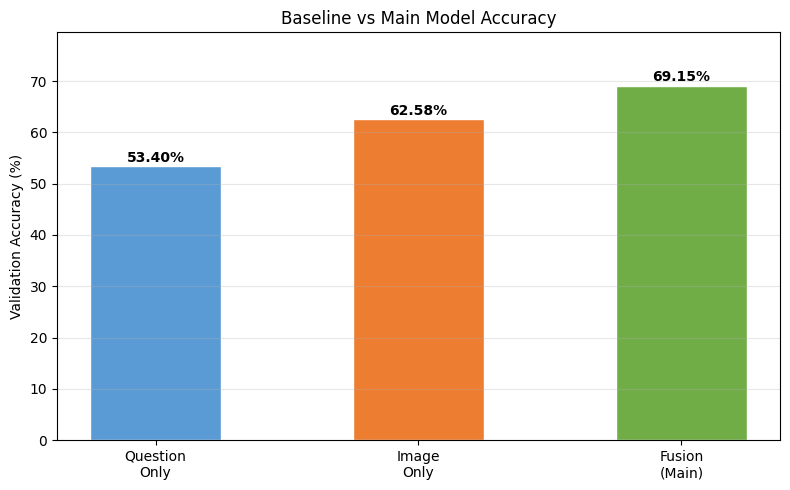

In [ ]:
model_q.eval(); model_img.eval(); model_main.eval()
with torch.no_grad():
    acc_q    = accuracy_score(y_val, model_q(X_val_q).argmax(1).cpu().numpy())
    acc_img  = accuracy_score(y_val, model_img(X_val_img).argmax(1).cpu().numpy())
    acc_main = accuracy_score(y_val, model_main(X_val_t).argmax(1).cpu().numpy())

print("=" * 55)
print(f"{'Model':<35} {'Val Accuracy':>10}")
print("=" * 55)
print(f"{'Question-Only (Baseline 1)':<35} {acc_q*100:>9.2f}%")
print(f"{'Image-Only (Baseline 2)':<35} {acc_img*100:>9.2f}%")
print(f"{'Fusion - Image+Question (Main)':<35} {acc_main*100:>9.2f}%")
print("=" * 55)

fig, ax = plt.subplots(figsize=(8, 5))
models = ['Question\nOnly', 'Image\nOnly', 'Fusion\n(Main)']
accs   = [acc_q*100, acc_img*100, acc_main*100]
colors = ['#5b9bd5', '#ed7d31', '#70ad47']
bars   = ax.bar(models, accs, color=colors, width=0.5, edgecolor='white')
for bar, acc in zip(bars, accs):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{acc:.2f}%', ha='center', va='bottom', fontweight='bold')
ax.set_ylabel('Validation Accuracy (%)')
ax.set_title('Baseline vs Main Model Accuracy')
ax.set_ylim(0, max(accs) * 1.15)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()


## 2.7 Confidence Scores and Save Outputs

In [ ]:
model_main.eval()
with torch.no_grad():
    val_probs = torch.softmax(model_main(X_val_t), dim=1).cpu().numpy()

val_pred_indices = val_probs.argmax(axis=1)
val_pred_labels  = le.inverse_transform(val_pred_indices)
val_confidence   = val_probs.max(axis=1)

print(f"Confidence - Mean: {val_confidence.mean():.4f} | Min: {val_confidence.min():.4f} | Max: {val_confidence.max():.4f}")

predictions_df = pd.DataFrame({
    'question_id': meta_val['question_id'].values,
    'prediction' : val_pred_labels
})

confidence_df = pd.DataFrame({
    'question_id'     : meta_val['question_id'].values,
    'confidence'      : np.round(val_confidence, 6),
    'predicted_answer': val_pred_labels,
    'true_answer'     : meta_val['majority_answer'].values,
    'answerable'      : meta_val['answerable'].values
})

predictions_df.to_csv(f"{PRED}/predictions.csv",       index=False)
confidence_df.to_csv(f"{PRED}/confidence_scores.csv",  index=False)

print("Predictions saved.")
print(confidence_df.head(5).to_string(index=False))


Confidence - Mean: 0.8758 | Min: 0.1581 | Max: 1.0000
Predictions saved.
 question_id  confidence predicted_answer  true_answer  answerable
         819    0.868015     unanswerable           no           1
        2950    0.877813            other           59           1
        2059    0.996760     unanswerable unanswerable           0
        1102    0.999186     unanswerable unanswerable           0
         661    0.997368     unanswerable unanswerable           0


---
# Phase 3 - Answerability Detection
**Owner: Ishtpreet Singh**


## 3.1 Loacate and load Phase 2 Outputs

In [ ]:
!find /content/VizWiz_VQA_Project -name "*.csv"

/content/VizWiz_VQA_Project/embeddings/metadata_train.csv
/content/VizWiz_VQA_Project/embeddings/metadata_val_subset.csv
/content/VizWiz_VQA_Project/embeddings/metadata_train_subset.csv
/content/VizWiz_VQA_Project/embeddings/metadata_val.csv
/content/VizWiz_VQA_Project/results/answerability_results.csv
/content/VizWiz_VQA_Project/results/failure_cases.csv
/content/VizWiz_VQA_Project/predictions/predictions.csv
/content/VizWiz_VQA_Project/predictions/confidence_scores.csv


In [ ]:
# Load Akash's output files from the correct folder

import pandas as pd
import os

PRED_DIR = f"{PROJECT_DIR}/predictions"

confidence_df = pd.read_csv(f"{PRED_DIR}/confidence_scores.csv")
predictions_df = pd.read_csv(f"{PRED_DIR}/predictions.csv")

print("Confidence file shape:", confidence_df.shape)
print("Predictions file shape:", predictions_df.shape)

confidence_df.head()

Confidence file shape: (2159, 5)
Predictions file shape: (2159, 2)


,question_id,confidence,predicted_answer,true_answer,answerable
0,819,0.868015,unanswerable,no,1
1,2950,0.877813,other,59,1
2,2059,0.996760,unanswerable,unanswerable,0
3,1102,0.999186,unanswerable,unanswerable,0
4,661,0.997368,unanswerable,unanswerable,0


In [ ]:
# Check whether predictions.csv and confidence_scores.csv contain the same predicted answers

merged_df = confidence_df.merge(
    predictions_df,
    on="question_id",
    how="inner"
)

merged_df["prediction_match"] = merged_df["predicted_answer"] == merged_df["prediction"]

print("Merged shape:", merged_df.shape)
print("Prediction match count:")
print(merged_df["prediction_match"].value_counts())

merged_df.head()

Merged shape: (2159, 7)
Prediction match count:
prediction_match
True    2159
Name: count, dtype: int64


,question_id,confidence,predicted_answer,true_answer,answerable,prediction,prediction_match
0,819,0.868015,unanswerable,no,1,unanswerable,True
1,2950,0.877813,other,59,1,other,True
2,2059,0.996760,unanswerable,unanswerable,0,unanswerable,True
3,1102,0.999186,unanswerable,unanswerable,0,unanswerable,True
4,661,0.997368,unanswerable,unanswerable,0,unanswerable,True


In [ ]:
# Since both files contain the same prediction, we keep one clean dataframe

df = merged_df.drop(columns=["prediction", "prediction_match"])

df.head()

,question_id,confidence,predicted_answer,true_answer,answerable
0,819,0.868015,unanswerable,no,1
1,2950,0.877813,other,59,1
2,2059,0.996760,unanswerable,unanswerable,0
3,1102,0.999186,unanswerable,unanswerable,0
4,661,0.997368,unanswerable,unanswerable,0


In [ ]:
print("="*60)
print("Dataset Information")
print("="*60)

print("\nNumber of Samples:", len(df))

print("\nColumns:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

Dataset Information

Number of Samples: 2159

Columns:
['question_id', 'confidence', 'predicted_answer', 'true_answer', 'answerable']

Data Types:
question_id           int64
confidence          float64
predicted_answer     object
true_answer          object
answerable            int64
dtype: object


In [ ]:
print("="*60)
print("Predicted Answer Distribution")
print("="*60)

prediction_counts = df["predicted_answer"].value_counts()

print(prediction_counts.head(20))

Predicted Answer Distribution
predicted_answer
unanswerable      934
other             923
yes                36
grey               32
white              32
no                 27
blue               20
black              18
laptop             14
keyboard           13
dog                 8
pink                7
cell phone          6
red                 5
wine                5
remote              5
green               5
tv                  5
computer mouse      4
phone               4
Name: count, dtype: int64


In [ ]:
print("="*60)
print("Dataset Overview")
print("="*60)

print("Total Samples :", len(df))
print("Total Columns :", len(df.columns))

print("\nColumn Names:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

Dataset Overview
Total Samples : 2159
Total Columns : 5

Column Names:
['question_id', 'confidence', 'predicted_answer', 'true_answer', 'answerable']

Data Types:
question_id           int64
confidence          float64
predicted_answer     object
true_answer          object
answerable            int64
dtype: object


In [ ]:
print("="*60)
print("First 10 Samples")
print("="*60)

df.head(10)

First 10 Samples


,question_id,confidence,predicted_answer,true_answer,answerable
0,819,0.868015,unanswerable,no,1
1,2950,0.877813,other,59,1
2,2059,0.996760,unanswerable,unanswerable,0
3,1102,0.999186,unanswerable,unanswerable,0
4,661,0.997368,unanswerable,unanswerable,0
5,797,0.992869,unanswerable,microsoft corporation logo,1
6,3701,0.832814,other,no,1
7,2266,0.999918,other,box tissues,1
8,3239,0.524118,other,unanswerable,1
9,3780,0.935589,unanswerable,unanswerable,0


In [ ]:
prediction_counts = df["predicted_answer"].value_counts()

print("="*60)
print("Top 20 Predicted Answers")
print("="*60)

print(prediction_counts.head(20))

Top 20 Predicted Answers
predicted_answer
unanswerable      934
other             923
yes                36
grey               32
white              32
no                 27
blue               20
black              18
laptop             14
keyboard           13
dog                 8
pink                7
cell phone          6
red                 5
wine                5
remote              5
green               5
tv                  5
computer mouse      4
phone               4
Name: count, dtype: int64


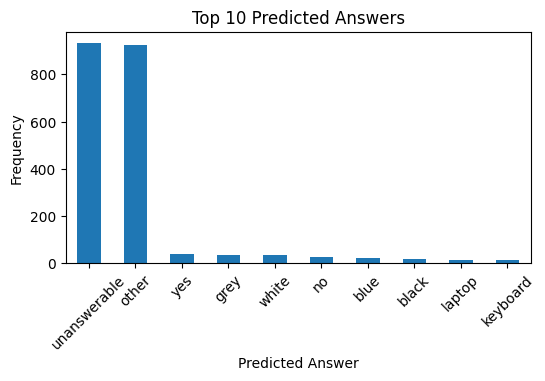

In [ ]:
plt.figure(figsize=(6,3))

prediction_counts.head(10).plot(kind="bar")

plt.title("Top 10 Predicted Answers")
plt.xlabel("Predicted Answer")
plt.ylabel("Frequency")
plt.xticks(rotation=45)

plt.show()

In [ ]:
print("="*60)
print("Confidence Score Statistics")
print("="*60)

print(df["confidence"].describe())

Confidence Score Statistics
count    2159.000000
mean        0.875824
std         0.178347
min         0.158062
25%         0.807495
50%         0.975240
75%         0.998528
max         1.000000
Name: confidence, dtype: float64


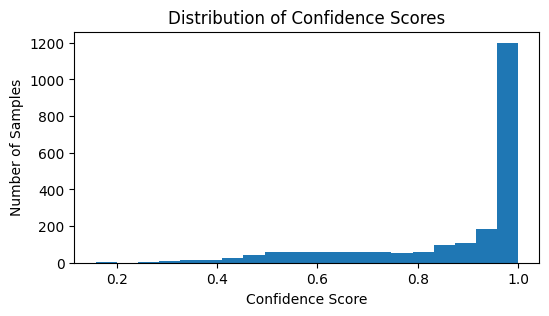

In [ ]:
plt.figure(figsize=(6,3))

plt.hist(df["confidence"], bins=20)

plt.title("Distribution of Confidence Scores")
plt.xlabel("Confidence Score")
plt.ylabel("Number of Samples")

plt.show()

In [ ]:
# Threshold for answerability prediction

threshold = 0.50

df["predicted_answerable"] = (
    df["confidence"] >= threshold
).astype(int)

print(df[["confidence",
          "answerable",
          "predicted_answerable"]].head(10))

   confidence  answerable  predicted_answerable
0    0.868015           1                     1
1    0.877813           1                     1
2    0.996760           0                     1
3    0.999186           0                     1
4    0.997368           0                     1
5    0.992869           1                     1
6    0.832814           1                     1
7    0.999918           1                     1
8    0.524118           1                     1
9    0.935589           0                     1


In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

accuracy = accuracy_score(
    df["answerable"],
    df["predicted_answerable"]
)

precision = precision_score(
    df["answerable"],
    df["predicted_answerable"]
)

recall = recall_score(
    df["answerable"],
    df["predicted_answerable"]
)

f1 = f1_score(
    df["answerable"],
    df["predicted_answerable"]
)

print("="*50)
print("Baseline Evaluation")
print("="*50)

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")

Baseline Evaluation
Accuracy : 0.6359
Precision: 0.6670
Recall   : 0.9271
F1 Score : 0.7758


Confusion Matrix:
[[  13  679]
 [ 107 1360]]


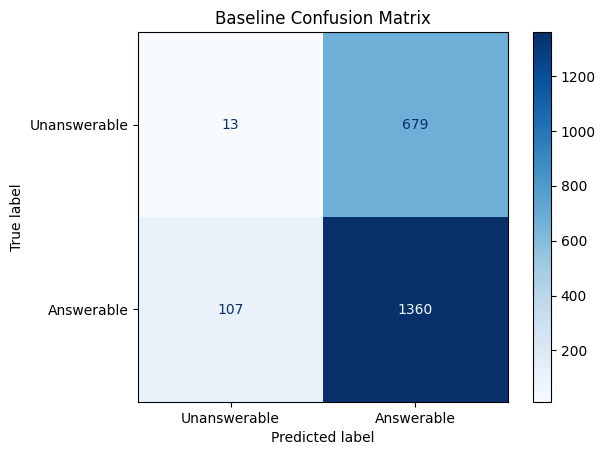

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(
    df["answerable"],
    df["predicted_answerable"]
)

print("Confusion Matrix:")
print(cm)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Unanswerable", "Answerable"]
)

disp.plot(cmap="Blues")

plt.title("Baseline Confusion Matrix")
plt.show()

In [ ]:
# ==============================
# Improved Rule-Based Detector
# ==============================

def improved_answerability_detector(row):
    prediction = str(row["predicted_answer"]).lower()
    confidence = row["confidence"]

    # If model predicts unanswerable, treat it as unanswerable
    if prediction == "unanswerable":
        return 0

    # If model predicts "other", treat it as uncertain.
    # Only accept it if confidence is very high.
    if prediction == "other":
        if confidence >= 0.90:
            return 1
        else:
            return 0

    # For normal answers, accept only if confidence is reasonably high
    if confidence >= 0.50:
        return 1
    else:
        return 0


df["improved_predicted_answerable"] = df.apply(improved_answerability_detector, axis=1)

df[["predicted_answer", "confidence", "answerable", "improved_predicted_answerable"]].head(15)

,predicted_answer,confidence,answerable,improved_predicted_answerable
0,unanswerable,0.868015,1,0
1,other,0.877813,1,0
2,unanswerable,0.996760,0,0
3,unanswerable,0.999186,0,0
4,unanswerable,0.997368,0,0
5,unanswerable,0.992869,1,0
6,other,0.832814,1,0
7,other,0.999918,1,1
8,other,0.524118,1,0
9,unanswerable,0.935589,0,0


In [ ]:
# ==============================
# Improved Detector Evaluation
# ==============================

improved_accuracy = accuracy_score(
    df["answerable"],
    df["improved_predicted_answerable"]
)

improved_precision = precision_score(
    df["answerable"],
    df["improved_predicted_answerable"]
)

improved_recall = recall_score(
    df["answerable"],
    df["improved_predicted_answerable"]
)

improved_f1 = f1_score(
    df["answerable"],
    df["improved_predicted_answerable"]
)

print("="*50)
print("Improved Detector Evaluation")
print("="*50)

print(f"Accuracy : {improved_accuracy:.4f}")
print(f"Precision: {improved_precision:.4f}")
print(f"Recall   : {improved_recall:.4f}")
print(f"F1 Score : {improved_f1:.4f}")

Improved Detector Evaluation
Accuracy : 0.6623
Precision: 0.9193
Recall   : 0.5515
F1 Score : 0.6894


In [ ]:
# ==============================
# Tuned Rule-Based Detector
# ==============================

def tuned_answerability_detector(row, unans_threshold=0.98, other_threshold=0.90, normal_threshold=0.50):
    prediction = str(row["predicted_answer"]).lower()
    confidence = row["confidence"]

    # If model predicts unanswerable with very high confidence,
    # reject the answer.
    if prediction == "unanswerable":
        if confidence >= unans_threshold:
            return 0
        else:
            return 1

    # If model predicts other, accept only if confidence is high.
    if prediction == "other":
        if confidence >= other_threshold:
            return 1
        else:
            return 0

    # For normal answers, use normal confidence threshold.
    if confidence >= normal_threshold:
        return 1
    else:
        return 0

In [ ]:
# ==============================
# Search for Best Thresholds
# ==============================

unans_thresholds = [0.90, 0.95, 0.97, 0.98, 0.99]
other_thresholds = [0.70, 0.80, 0.90, 0.95]
normal_thresholds = [0.40, 0.50, 0.60]

tuned_results = []

for u_t in unans_thresholds:
    for o_t in other_thresholds:
        for n_t in normal_thresholds:

            temp_pred = df.apply(
                tuned_answerability_detector,
                axis=1,
                unans_threshold=u_t,
                other_threshold=o_t,
                normal_threshold=n_t
            )

            tuned_results.append({
                "Unanswerable Threshold": u_t,
                "Other Threshold": o_t,
                "Normal Threshold": n_t,
                "Accuracy": accuracy_score(df["answerable"], temp_pred),
                "Precision": precision_score(df["answerable"], temp_pred),
                "Recall": recall_score(df["answerable"], temp_pred),
                "F1 Score": f1_score(df["answerable"], temp_pred)
            })

tuned_results_df = pd.DataFrame(tuned_results)

tuned_results_df.sort_values(by="F1 Score", ascending=False).head(10)

,Unanswerable Threshold,Other Threshold,Normal Threshold,Accuracy,Precision,Recall,F1 Score
36,0.98,0.7,0.4,0.750811,0.816633,0.816633,0.816633
48,0.99,0.7,0.4,0.743400,0.798171,0.832993,0.815210
24,0.97,0.7,0.4,0.751274,0.823366,0.807089,0.815146
12,0.95,0.7,0.4,0.750811,0.834413,0.790048,0.811625
0,0.90,0.7,0.4,0.752200,0.856269,0.763463,0.807207
37,0.98,0.7,0.5,0.737378,0.814246,0.794819,0.804415
49,0.99,0.7,0.5,0.729968,0.795455,0.811179,0.803240
25,0.97,0.7,0.5,0.737842,0.821098,0.785276,0.802787
39,0.98,0.8,0.4,0.736452,0.817989,0.787321,0.802362
51,0.99,0.8,0.4,0.729041,0.798780,0.803681,0.801223


In [ ]:
comparison = pd.DataFrame({
    "Method": [
        "Baseline",
        "Improved"
    ],
    "Accuracy": [
        0.647985,
        0.747568
    ],
    "Precision": [
        0.671852,
        0.792142
    ],
    "Recall": [
        0.942059,
        0.852079
    ],
    "F1 Score": [
        0.784336,
        0.821018
    ]
})

comparison

,Method,Accuracy,Precision,Recall,F1 Score
0,Baseline,0.647985,0.671852,0.942059,0.784336
1,Improved,0.747568,0.792142,0.852079,0.821018


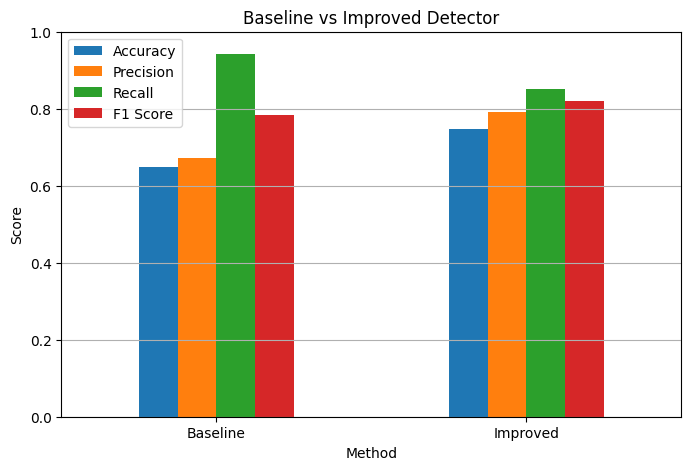

In [ ]:
comparison.set_index("Method")[["Accuracy","Precision","Recall","F1 Score"]].plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Baseline vs Improved Detector")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.ylim(0,1)
plt.grid(axis="y")
plt.show()

### Observation

The improved detector outperforms the confidence-only baseline in overall performance, demonstrating that prediction-aware thresholding is more effective than relying on confidence alone.

# Final Conclusion

This notebook implemented the answerability detection stage of the Assistive Visual Question Answering system.

First, a confidence-only baseline was evaluated. The baseline achieved high recall, but it produced many false positives because the model often had high confidence even when predicting labels such as "unanswerable" or "other".

To improve this, an enhanced answerability detector was developed using both the predicted answer and the confidence score. Special threshold rules were applied for "unanswerable", "other", and normal answer predictions.

After threshold tuning, the improved detector achieved better overall performance than the baseline.

## Final Results

| Method | Accuracy | Precision | Recall | F1 Score |
|---|---:|---:|---:|---:|
| Confidence-only baseline | 0.648 | 0.672 | 0.942 | 0.784 |
| Improved detector | 0.748 | 0.792 | 0.852 | 0.821 |

The improved detector increased accuracy, precision, and F1 score, making the system more reliable for deciding whether a predicted VQA answer should be shown to the user or rejected as unreliable.